# Step 1: Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# Step 2: Load Dataset
- since I have 90 images of each (approx) in training, I will keep batch size small (8)

In [3]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    "temp/data_cats_dogs_small/train",
    image_size=(224, 224),
    batch_size=8
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    "temp/data_cats_dogs_small/val",
    image_size=(224, 224),
    batch_size=8
)


Found 180 files belonging to 2 classes.
Found 69 files belonging to 2 classes.


# Step 3: Load Pretrained Model

In [4]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)


# step4: Freeze Base Model

In [5]:
base_model.trainable = False

# Step 5: Add Custom Layers

In [6]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(2, activation='softmax')
])


# Step 6: Compile Model

In [18]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# Step 7: Train

In [19]:
model.fit(train_data, validation_data=val_data, epochs=8)

Epoch 1/8
23/23 [==============================] - 10s 206ms/step - loss: 1.2968 - accuracy: 0.6833 - val_loss: 2.2208 - val_accuracy: 0.6667
Epoch 2/8
23/23 [==============================] - 4s 152ms/step - loss: 0.4481 - accuracy: 0.8056 - val_loss: 3.5777 - val_accuracy: 0.4928
Epoch 3/8
23/23 [==============================] - 4s 151ms/step - loss: 0.2429 - accuracy: 0.9167 - val_loss: 5.6937 - val_accuracy: 0.4638
Epoch 4/8
23/23 [==============================] - 4s 154ms/step - loss: 0.3652 - accuracy: 0.8889 - val_loss: 4.0602 - val_accuracy: 0.4783
Epoch 5/8
23/23 [==============================] - 4s 160ms/step - loss: 0.3762 - accuracy: 0.8444 - val_loss: 1.8119 - val_accuracy: 0.6087
Epoch 6/8
23/23 [==============================] - 4s 172ms/step - loss: 0.1976 - accuracy: 0.9389 - val_loss: 5.2042 - val_accuracy: 0.5507
Epoch 7/8
23/23 [==============================] - 4s 169ms/step - loss: 0.2757 - accuracy: 0.9278 - val_loss: 6.6215 - val_accuracy: 0.4928
Epoch 8/8
23

# Lets test on few images
- pic1 pic2 pic3 pic4

In [29]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "pic3.jpg"  # Test on pic1 pic2 pic3 pic4

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)

# Add batch dimension (VERY IMPORTANT)
img_array = np.expand_dims(img_array, axis=0)

# Normalize (same as training)
img_array = img_array / 255.0

prediction = model.predict(img_array)

print(prediction) # probablities for [cat,dog]

1/1 [==============================] - 0s 99ms/step
[[1.687078e-09 1.000000e+00]]


In [30]:
class_names = ["cat", "dog"]  # VERY IMPORTANT: same order as training

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)

print(f"Prediction: {predicted_class}")
print(f"Confidence: {confidence:.2f}")

Prediction: dog
Confidence: 1.00


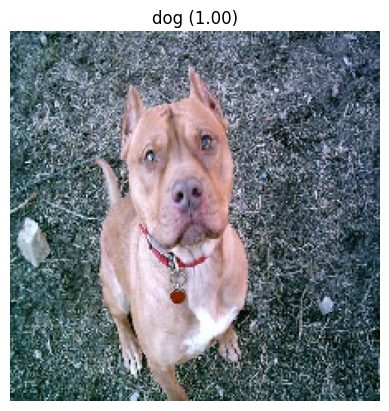

In [31]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f})")
plt.axis('off')
plt.show()


# Lets do above on images in test directory

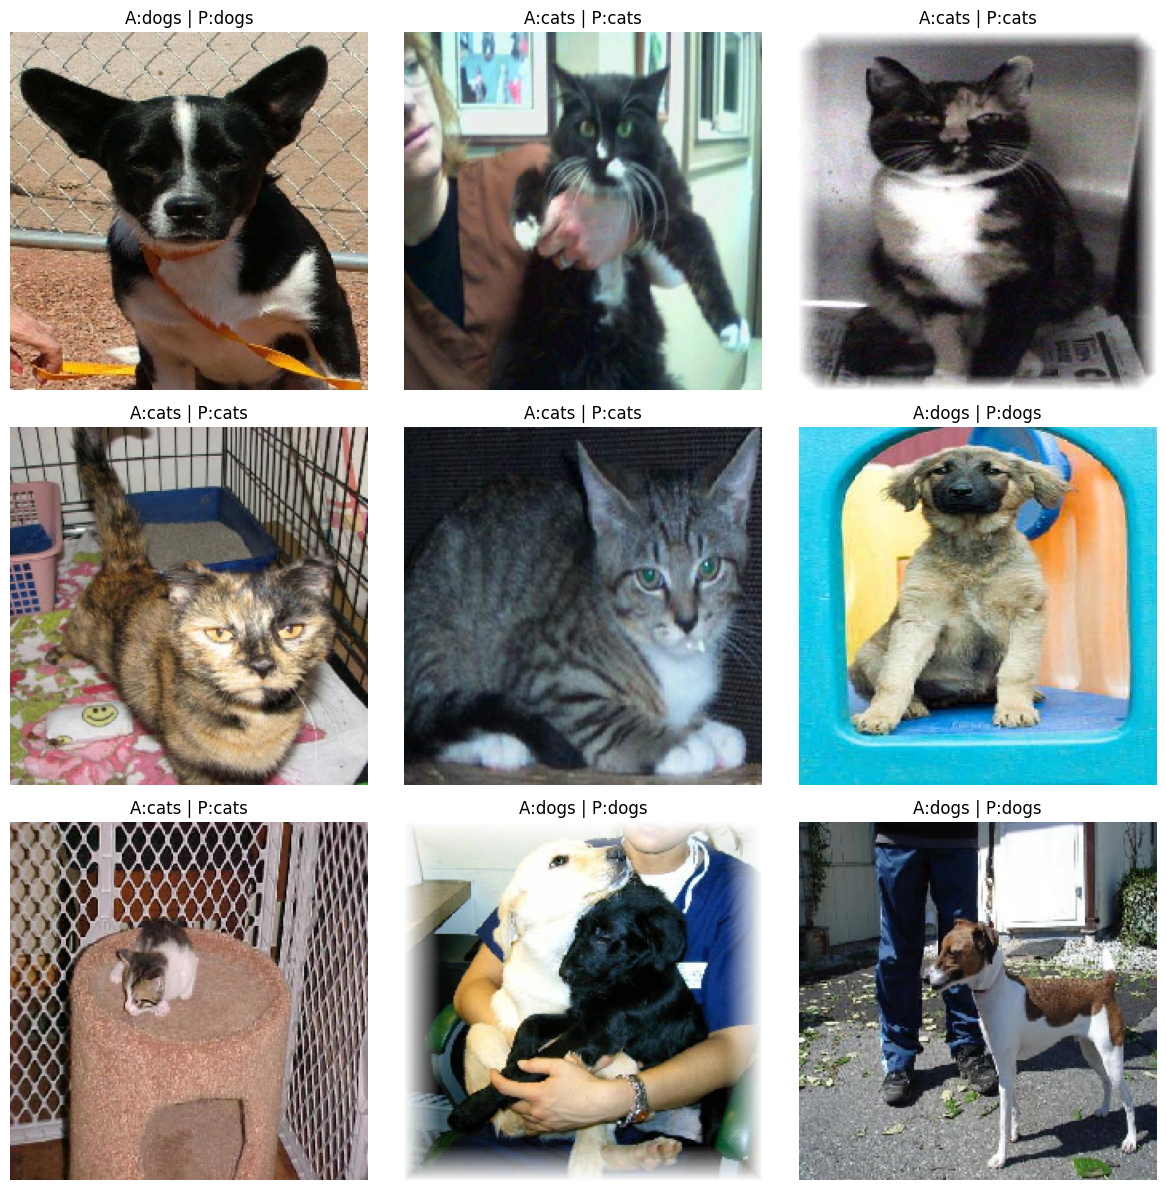

In [40]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

test_dir = "temp/data_cats_dogs_small/test"
class_names = train_data.class_names

files = [f for f in os.listdir(test_dir) if f.endswith(".jpg")]

# pick random 9 images
random_files = random.sample(files, 9)

plt.figure(figsize=(12, 12))

for i, file in enumerate(random_files):  # show 9 images
    img_path = os.path.join(test_dir, file)

    # actual label
    actual = "cats" if "cat" in file.lower() else "dogs"

    # load + preprocess
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    # predict
    pred = model.predict(img_array, verbose=0)
    predicted = class_names[np.argmax(pred)]

    # plot
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.title(f"A:{actual} | P:{predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()


# Check accuracy

In [38]:
y_true = []
y_pred = []

for file in files:
    if file.endswith(".jpg"):
        img_path = os.path.join(test_dir, file)

        # actual label
        actual = 0 if "cat" in file.lower() else 1
        y_true.append(actual)

        # load image
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = preprocess_input(img_array)
        img_array = np.expand_dims(img_array, axis=0)

        # predict
        pred = model.predict(img_array, verbose=0)
        predicted = np.argmax(pred)

        if actual != predicted:
            print("Wrong:", file)


        y_pred.append(predicted)

# accuracy
accuracy = np.mean(np.array(y_true) == np.array(y_pred))
print(f"Test Accuracy: {accuracy:.2f}")

Wrong: dog.4028.jpg
Test Accuracy: 0.95


# Plot confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot()
plt.show()

# STOP